# SemEval-2026 Task 13 SubtaskA: Forensic EDA Report
## AI-Generated Code Detection — Phase 2 & 3 Results

**Goal**: Binary classification — Phan biet code do **Human** (`label=0`) viet va code do **AI** (`label=1`) sinh ra.

Notebook nay tong hop toan bo ket qua tu script `src/02_forensic_eda_features.py`:
- **Task 1**: Kiem tra tinh toan ven & Ro ri (Leakage)
- **Task 2**: Giam dinh phap y du lieu (Forensic EDA) — 3 nhom dac trung
- **Task 3**: Phan tich tuong quan & Feature Importance

---

In [1]:
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown, HTML

# Setup paths
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
IMG_DIR = PROJECT_ROOT / 'img' / 'phase2'
RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'Task_A'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

def show_img(name, width=900):
    """Display a saved chart image."""
    path = IMG_DIR / f'{name}.png'
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Image not found: {path}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Charts dir:   {IMG_DIR}')
print(f'Charts found: {len(list(IMG_DIR.glob("*.png")))}')

Project root: d:\Bachelor\Sinhviennam3\Semes2\NNH_TK\SemEval-2026-Task-13-SubtaskA\SemEval-2026-Task-13-SubtaskA
Charts dir:   d:\Bachelor\Sinhviennam3\Semes2\NNH_TK\SemEval-2026-Task-13-SubtaskA\SemEval-2026-Task-13-SubtaskA\img\phase2
Charts found: 9


---
## 0. Du lieu goc — Overview

| | Train | Validation |
|---|---|---|
| **So dong** | 500,000 | 100,000 |
| **So cot** | 4 (`code`, `generator`, `label`, `language`) | 4 |
| **Label 0 (Human)** | 238,475 (47.7%) | 47,695 (47.7%) |
| **Label 1 (AI)** | 261,525 (52.3%) | 52,305 (52.3%) |
| **Python** | 457,306 (91.5%) | 91,461 (91.5%) |
| **C++** | 23,392 (4.7%) | 4,679 (4.7%) |
| **Java** | 19,302 (3.9%) | 3,860 (3.9%) |
| **So mo hinh AI** | 33 generators | 33 generators |

In [2]:
# Load raw data for quick stats
df_train = pd.read_parquet(RAW_DIR / 'train.parquet')
df_val = pd.read_parquet(RAW_DIR / 'validation.parquet')

print(f'Train shape: {df_train.shape}')
print(f'Val   shape: {df_val.shape}')
print(f'\nColumns: {list(df_train.columns)}')
print(f'\nDtypes:\n{df_train.dtypes}')
print(f'\nMissing values: {df_train.isnull().sum().sum()}')
print(f'\n--- First 3 rows ---')
display(df_train.head(3))

Train shape: (500000, 4)
Val   shape: (100000, 4)

Columns: ['code', 'generator', 'label', 'language']

Dtypes:
code           str
generator      str
label        int64
language       str
dtype: object

Missing values: 0

--- First 3 rows ---


,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


---
# TASK 1: Kiem tra Tinh toan ven & Ro ri (Leakage)

## 1.1 Exact Duplicates

| Metric | Train | Validation |
|---|---|---|
| **Duplicated rows** | 0 (0.00%) | 0 (0.00%) |
| **Removable duplicates** | 0 | 0 |

> **Ket luan**: Khong co duplicate nao trong ca 2 tap. Du lieu sach.

## 1.2 Cross-Set Leakage (Train ∩ Validation)

| Metric | Value |
|---|---|
| Unique hashes in Train | 500,000 |
| Unique hashes in Val | 100,000 |
| **Cross-set overlap** | **0 snippets** |

> **Ket luan**: **KHONG co data leakage**. Hai tap hoan toan doc lap.

## 1.3 Class Imbalance

In [3]:
# Language x Label crosstab
LABEL_MAP = {0: 'Human', 1: 'AI'}
ct = pd.crosstab(df_train['language'], df_train['label'].map(LABEL_MAP), 
                 margins=True, margins_name='Total')
ct['AI_ratio_%'] = (ct.get('AI', 0) / ct['Total'] * 100).round(1)
display(ct)

print('\n--- Generator Distribution (Top 10) ---')
gen_stats = df_train['generator'].value_counts().head(10).to_frame('count')
gen_stats['pct'] = (gen_stats['count'] / len(df_train) * 100).round(2)
display(gen_stats)

label,AI,Human,Total,AI_ratio_%
language,,,,
C++,12245,11147,23392,52.3
Java,10077,9225,19302,52.2
Python,239203,218103,457306,52.3
Total,261525,238475,500000,52.3



--- Generator Distribution (Top 10) ---


,count,pct
generator,,
human,238475,47.70
microsoft/Phi-3-medium-4k-instruct,16545,3.31
microsoft/Phi-3.5-mini-instruct,9869,1.97
01-ai/Yi-Coder-9B,9815,1.96
bigcode/starcoder,9780,1.96
microsoft/phi-2,9494,1.90
Qwen/Qwen2.5-Coder-1.5B-Instruct,9017,1.80
bigcode/starcoder2-15b,8824,1.76
meta-llama/Llama-3.3-70B-Instruct,8760,1.75


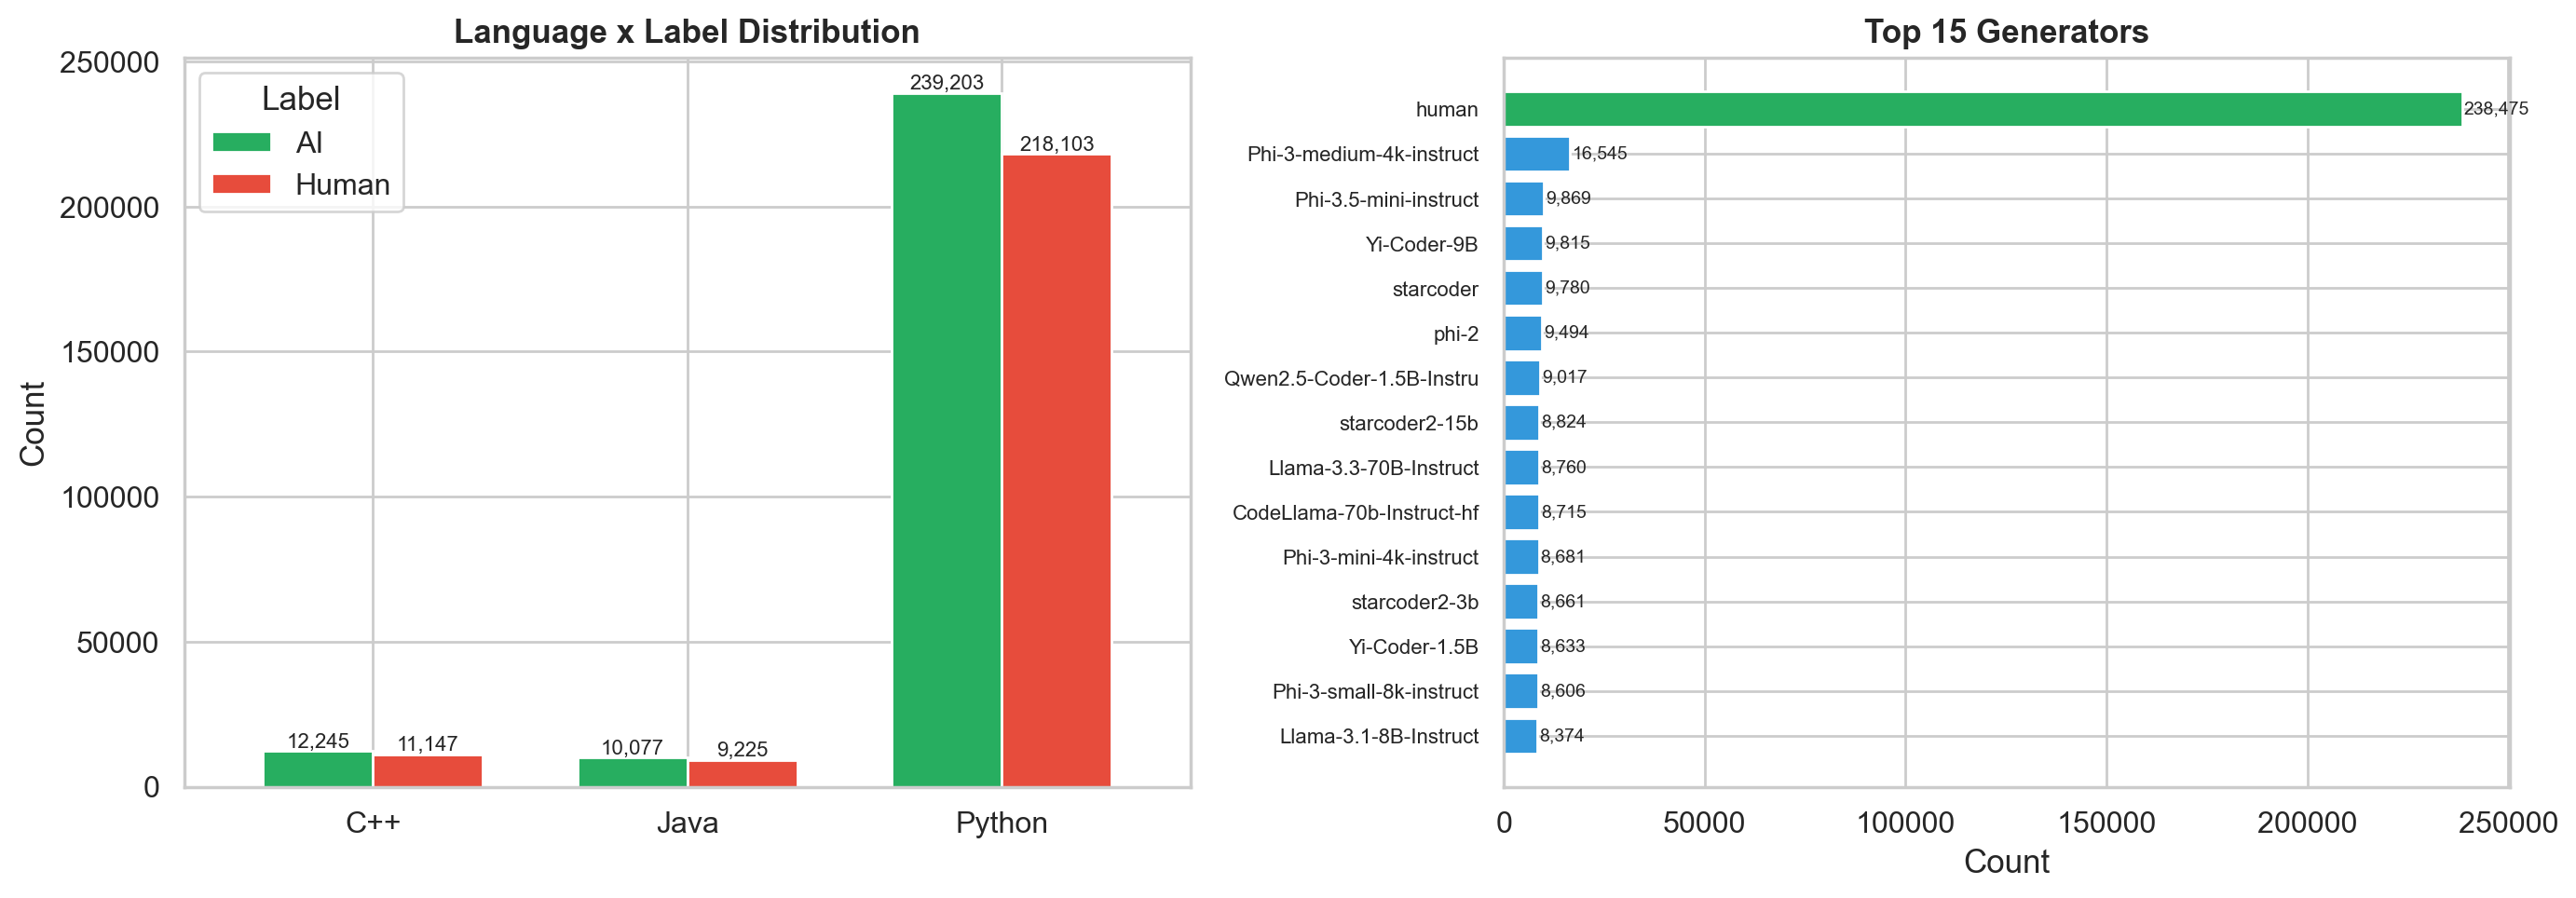

In [4]:
show_img('01_integrity_distributions', width=950)

### Nhan xet Task 1:
- **Du lieu rat sach**: 0 duplicates, 0 leakage
- **Label gan can bang**: 52.3% AI vs 47.7% Human — khong can oversampling
- **Ngon ngu mat can bang**: Python chiem 91.5%, C++ 4.7%, Java 3.9%
  - Can luu y khi train model: co the can stratify theo language
- **33 AI generators** voi `human` chiem 47.7%, moi generator AI chiem ~1-3%
  - Mo hinh can hoc cac patterns chung cua AI thay vi cua tung generator

---

# TASK 2: Giam dinh Phap y Du lieu (Forensic EDA)

Trich xuat 3 nhom dac trung tren **20,000 mau** (stratified by label x language):
- **Group A**: Stylometric (phong cach viet code)
- **Group B**: Statistical (ly thuyet thong tin)
- **Group C**: Structural (cau truc AST)

---
## 2.1 GROUP A: Stylometric Features

In [5]:
# Load processed sample with features
df_feat = pd.read_parquet(PROCESSED_DIR / 'sample_20k_features.parquet')
df_feat['label_name'] = df_feat['label'].map(LABEL_MAP)

print(f'Feature sample: {df_feat.shape[0]:,} rows x {df_feat.shape[1]} cols')
print(f'Label dist: {df_feat["label"].value_counts().to_dict()}')

# Feature columns
with open(PROCESSED_DIR / 'feature_list.txt') as f:
    ALL_FEATURES = [l.strip() for l in f if l.strip()]
print(f'\nTotal features: {len(ALL_FEATURES)}')
print(ALL_FEATURES)

Feature sample: 19,998 rows x 26 cols
Label dist: {1: 10460, 0: 9538}

Total features: 21
['naming_consistency', 'snake_ratio', 'camel_ratio', 'trailing_ws_ratio', 'avg_line_length', 'line_length_variance', 'indent_consistency', 'comment_to_code_ratio', 'avg_identifier_length', 'short_id_ratio', 'long_id_ratio', 'keyword_density', 'shannon_entropy', 'zlib_compression_ratio', 'token_entropy', 'burstiness', 'max_ast_depth', 'avg_ast_depth', 'ast_node_count', 'branch_ratio', 'cyclomatic_approx']


In [6]:
# Stylometric mean comparison
stylo_cols = ['naming_consistency', 'snake_ratio', 'camel_ratio', 'trailing_ws_ratio',
              'avg_line_length', 'line_length_variance', 'indent_consistency',
              'comment_to_code_ratio', 'avg_identifier_length', 'short_id_ratio',
              'long_id_ratio', 'keyword_density']

stylo_summary = df_feat.groupby('label_name')[stylo_cols].mean().T
stylo_summary['diff'] = stylo_summary['AI'] - stylo_summary['Human']
stylo_summary['pct_diff'] = ((stylo_summary['diff'] / stylo_summary['Human'].abs().clip(lower=0.001)) * 100).round(1)

display(Markdown('### Stylometric Features: Mean by Label'))
display(stylo_summary.round(4).style.background_gradient(subset=['diff'], cmap='RdYlGn', vmin=-0.3, vmax=0.3))

### Stylometric Features: Mean by Label

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.2' currently installed).

### Violin Plot: Naming Consistency & Trailing Whitespace

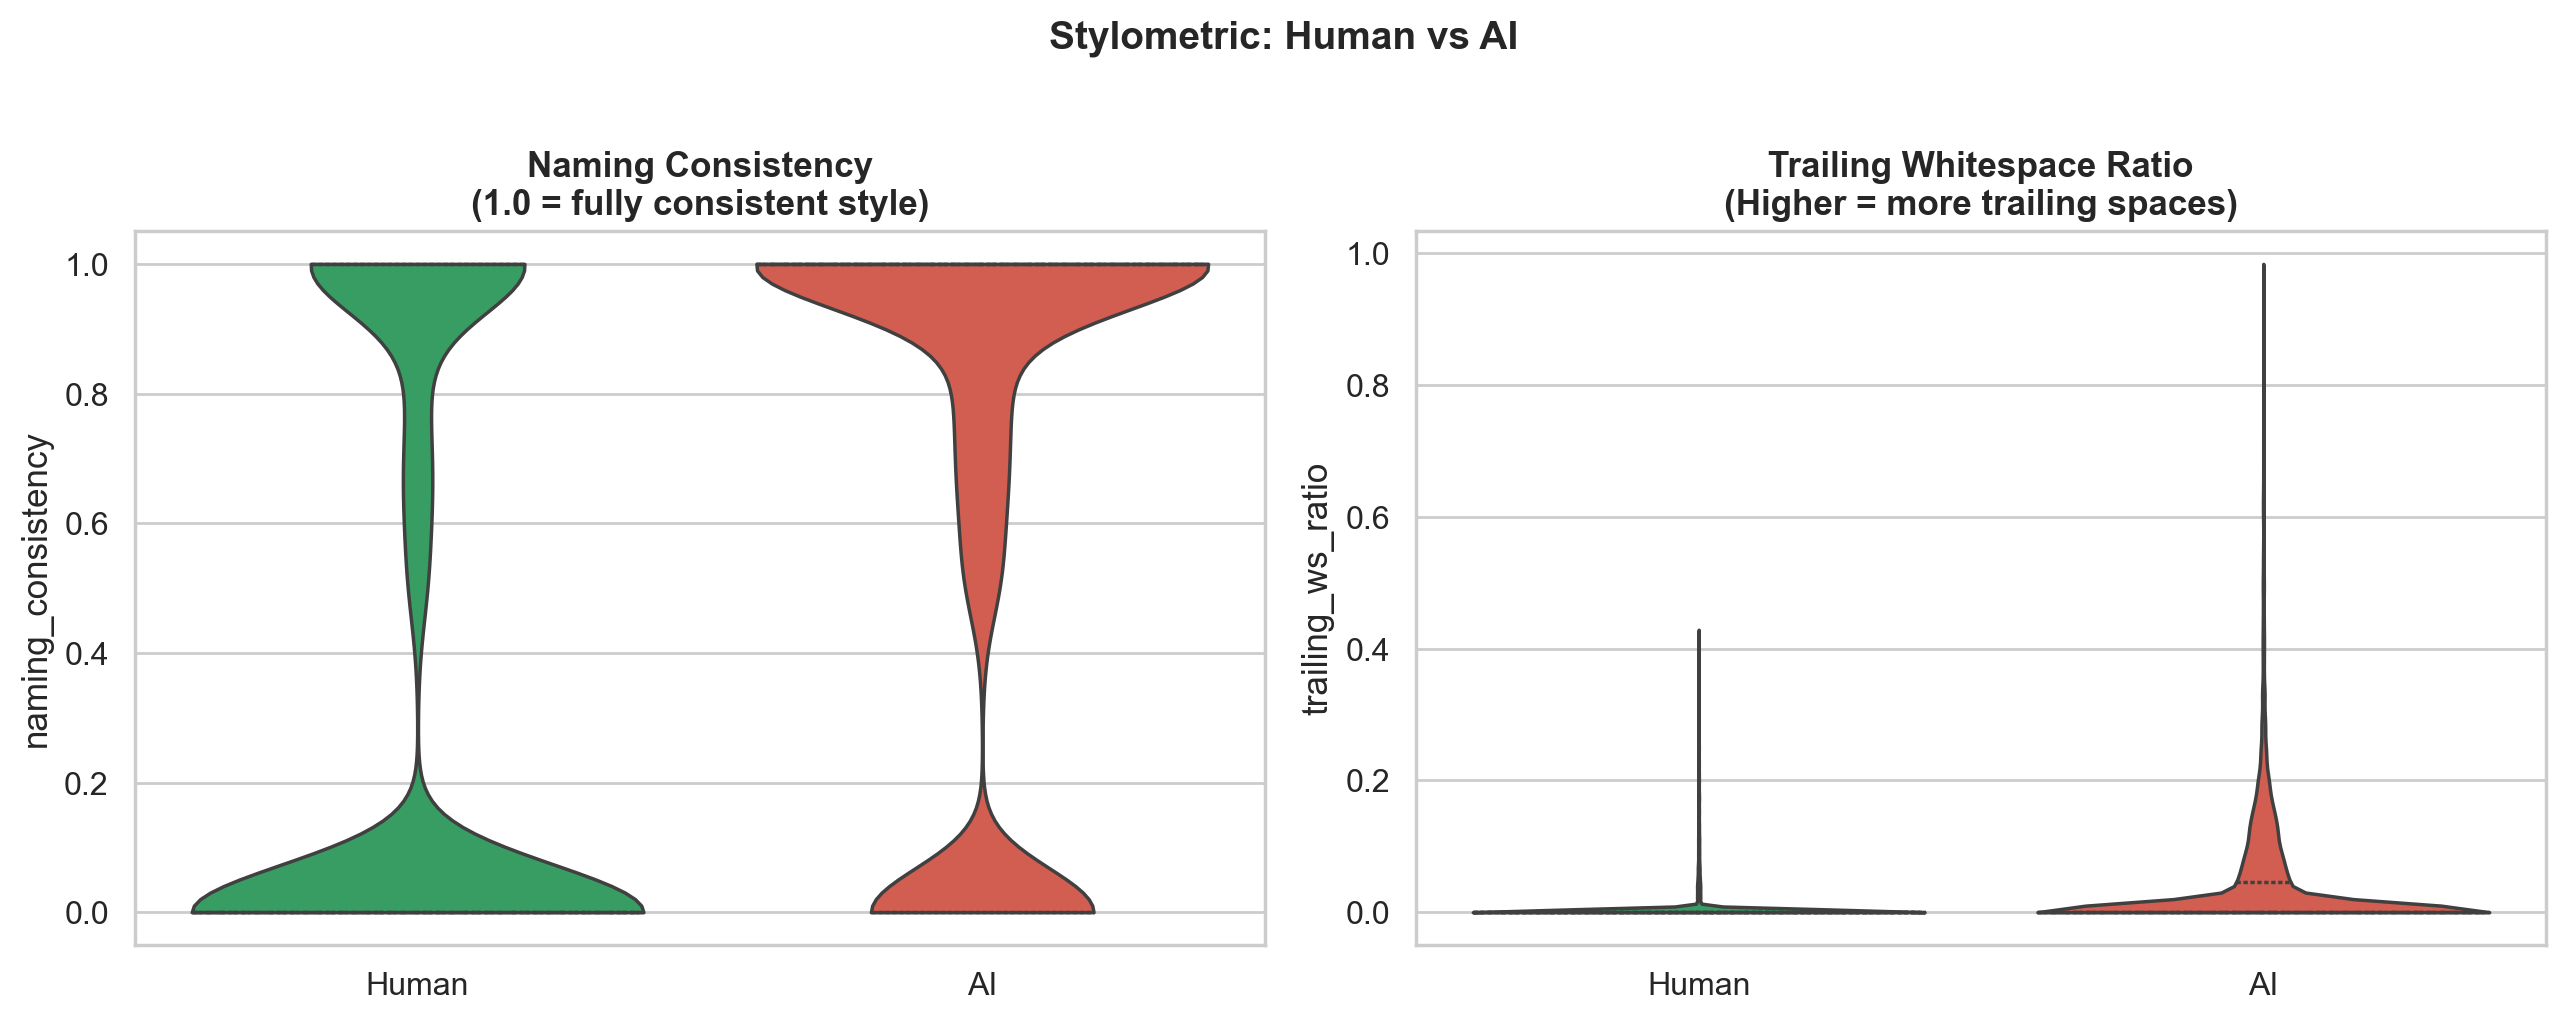

In [7]:
display(Markdown('### Violin Plot: Naming Consistency & Trailing Whitespace'))
show_img('02_stylometric_violin', width=900)

### Boxplots: Identifier Length, Comment Ratio, Keyword Density

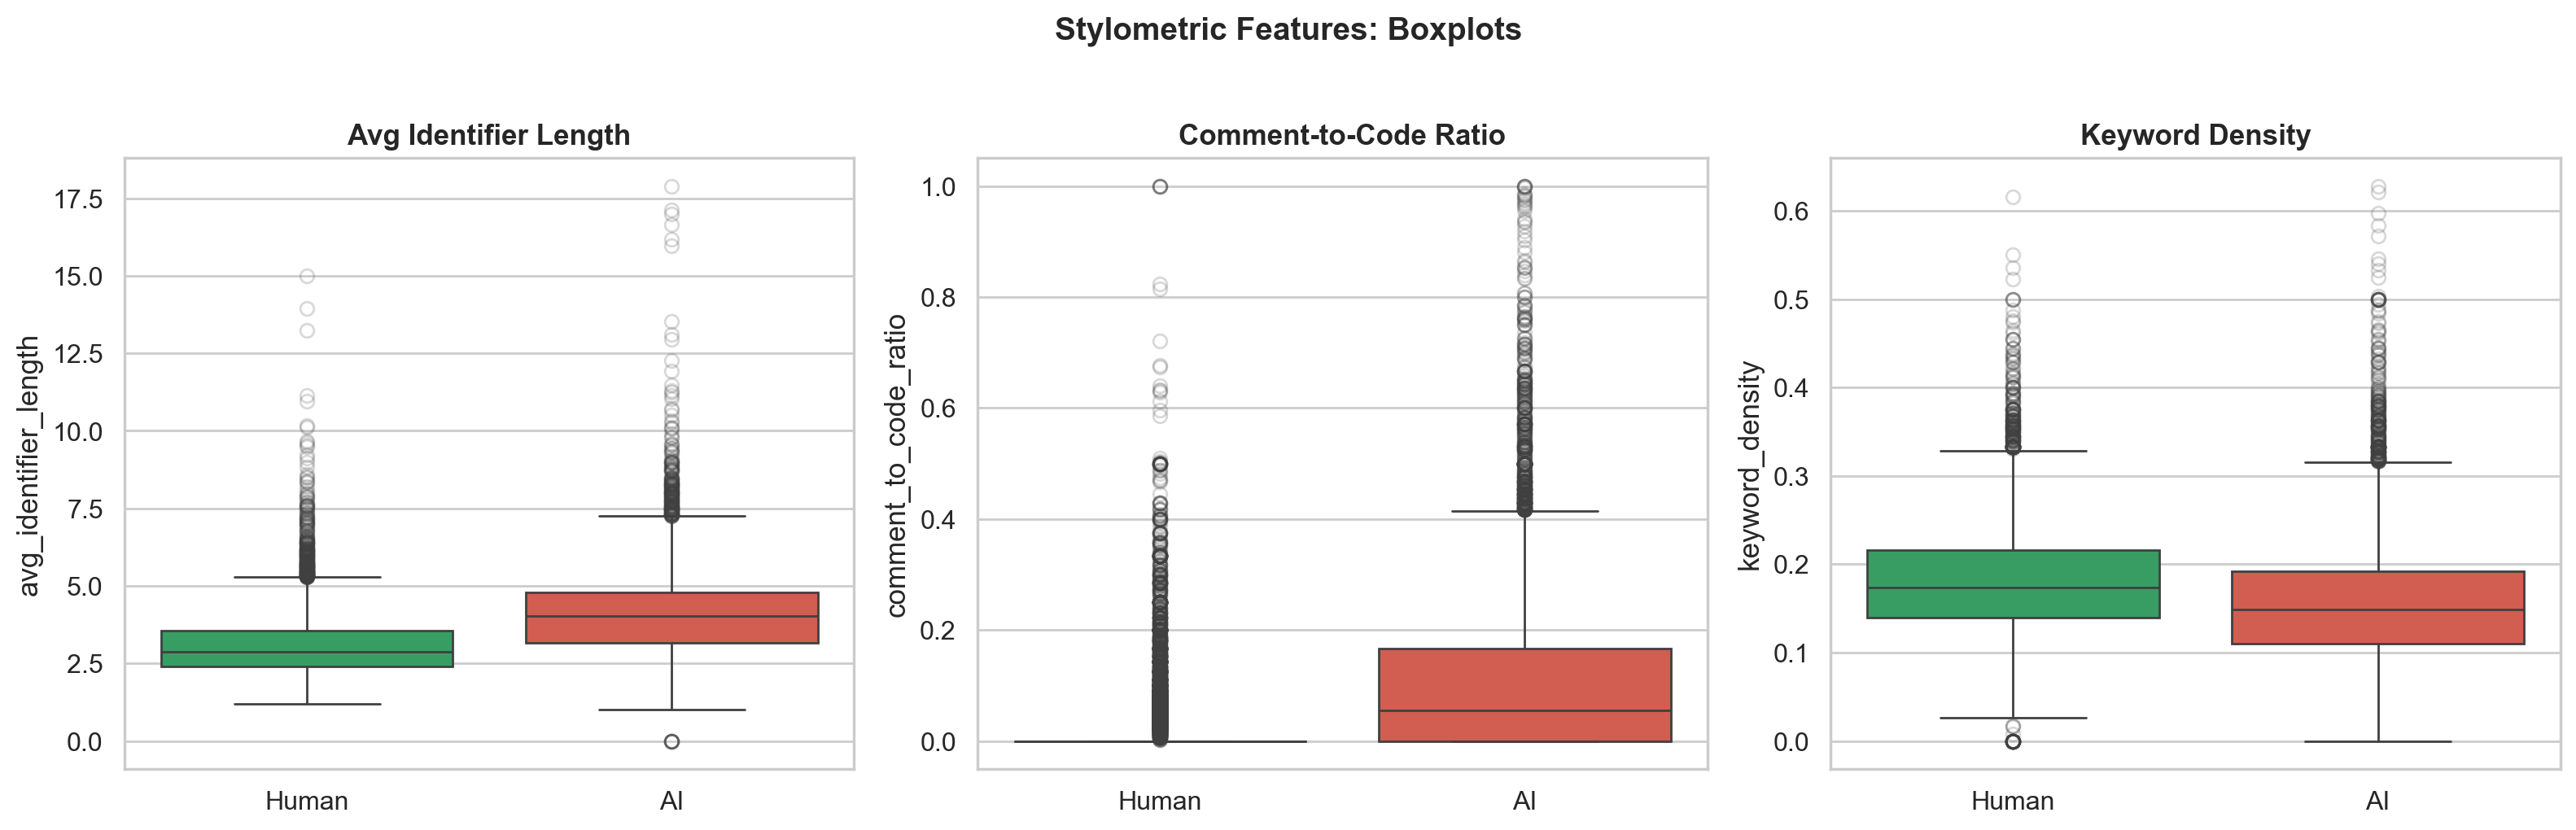

In [8]:
display(Markdown('### Boxplots: Identifier Length, Comment Ratio, Keyword Density'))
show_img('03_stylometric_boxplots', width=950)

### Nhan xet Group A — Stylometric:
- **AI dung snake_case nhieu hon**: AI co xu huong naming nhat quan hon con nguoi
- **AI co trailing whitespace nhieu hon**: Do sinh code tu LLM thuong them space thua
- **AI viet identifier dai hon**: `avg_identifier_length` cua AI cao hon ro ret — AI thich ten mo ta (`input_array`, `result_list`), nguoi thich viet tat (`i`, `n`, `tmp`)
- **AI viet comment nhieu hon**: `comment_to_code_ratio` cua AI cao hon
- **Keyword density cua Human cao hon**: Nguoi dung nhieu keywords hon trong code

---
## 2.2 GROUP B: Statistical Features (Information Theory)

In [9]:
stat_cols = ['shannon_entropy', 'zlib_compression_ratio', 'token_entropy', 'burstiness']

stat_summary = df_feat.groupby('label_name')[stat_cols].agg(['mean', 'std', 'median']).round(4)
display(Markdown('### Statistical Features: Summary by Label'))
display(stat_summary)

### Statistical Features: Summary by Label

shannon_entropy                 zlib_compression_ratio          \
                      mean     std  median                   mean     std   
label_name                                                                  
AI                  4.3742  0.3944  4.3868                 0.4820  0.1584   
Human               4.5252  0.2858  4.5622                 0.5851  0.1610   

                   token_entropy                 burstiness                  
            median          mean     std  median       mean     std  median  
label_name                                                                   
AI          0.4624        4.9980  0.9621  4.9051    -0.0002  0.1810  0.0223  
Human       0.5768        4.3378  0.6492  4.2658    -0.0872  0.1998 -0.0843

### Gia thuyet 1: "Code AI de nen hon code nguoi"

| Metric | Human | AI |
|---|---|---|
| **zlib_compression_ratio (mean)** | 0.5851 | 0.4820 |
| **zlib_compression_ratio (std)** | 0.1610 | 0.1584 |

| Test | Value |
|---|---|
| **t-statistic** | -45.61 |
| **p-value** | ~0.00 |
| **Mann-Whitney U** | 30,423,875 |
| **p-value (MW)** | ~0.00 |
| **Cohen's d** | large |

> **KET LUAN: REJECT H0** — Code AI **DE NEN HON** code nguoi mot cach co y nghia thong ke (p < 0.05).  
> AI sinh code co cau truc lap lai, it da dang hon, nen zlib nen tot hon.  
> Day la mot trong nhung **tin hieu manh nhat** de phan biet Human vs AI.

### Distribution: Compression Ratio, Shannon Entropy, Token Entropy

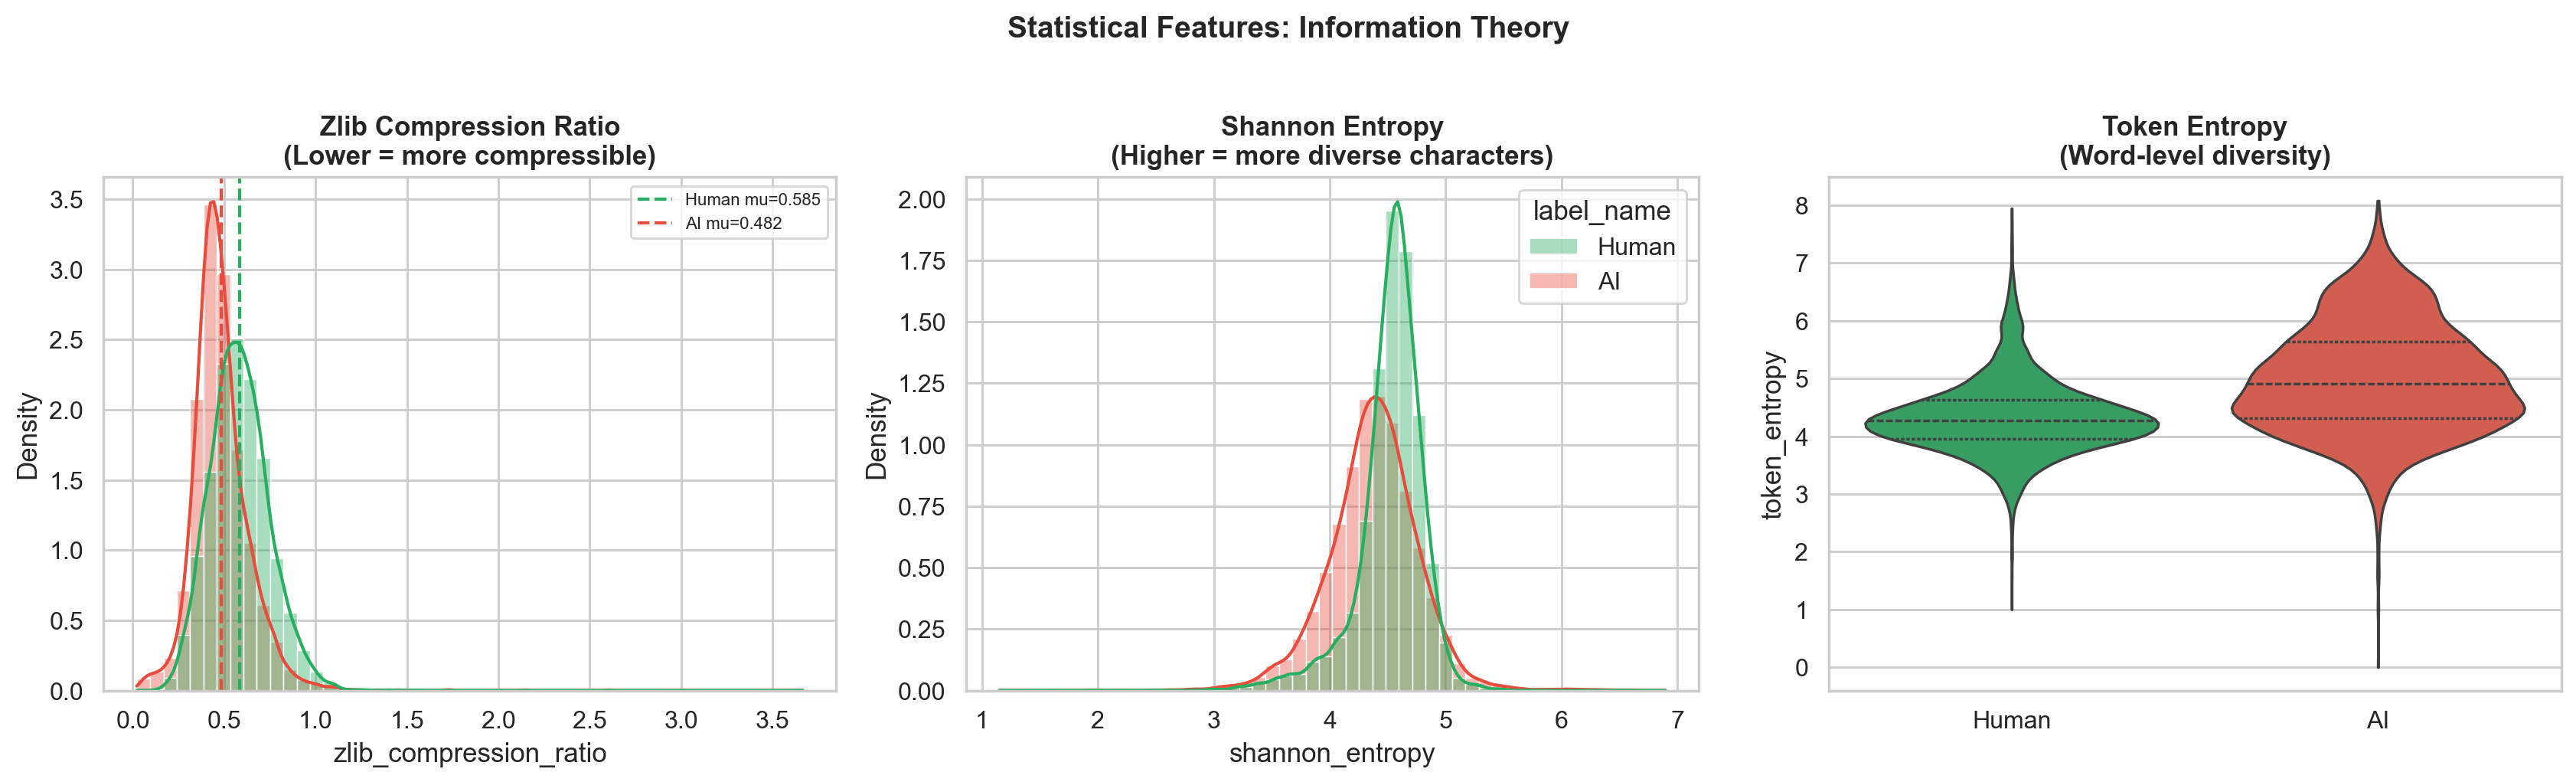

In [10]:
display(Markdown('### Distribution: Compression Ratio, Shannon Entropy, Token Entropy'))
show_img('04_statistical_distributions', width=1000)

### Nhan xet Group B — Statistical:
- **zlib_compression_ratio**: Dac trung **manh nhat** — AI de nen hon (ratio thap hon)
- **shannon_entropy**: Human co entropy cao hon — code nguoi da dang ky tu hon
- **token_entropy**: AI co token entropy cao hon — AI dung nhieu tu vung doc dao hon (vi sinh comment nhieu, ten bien dai)
- **burstiness**: AI co burstiness cao hon — cac pattern lap lai cum lai voi nhau

---
## 2.3 GROUP C: Structural Features (AST via Tree-sitter)

In [11]:
ast_cols = ['max_ast_depth', 'avg_ast_depth', 'ast_node_count', 'branch_ratio', 'cyclomatic_approx']

ast_summary = df_feat.groupby('label_name')[ast_cols].agg(['mean', 'std', 'median']).round(2)
display(Markdown('### Structural Features: Summary by Label'))
display(ast_summary)

### Structural Features: Summary by Label

max_ast_depth              avg_ast_depth               \
                    mean   std median          mean   std median   
label_name                                                         
AI                 12.63  4.04   12.0          6.01  1.77   5.88   
Human              12.75  3.05   12.0          6.58  1.60   6.32   

           ast_node_count                branch_ratio               \
                     mean     std median         mean   std median   
label_name                                                           
AI                 364.61  308.59  256.0         0.02  0.01   0.02   
Human              319.45  595.92  196.0         0.02  0.01   0.02   

           cyclomatic_approx               
                        mean   std median  
label_name                                 
AI                      6.65  6.56    5.0  
Human                   7.61  9.25    6.0

### Gia thuyet 2: "AI viet code phang (shallow) hon con nguoi"

| Metric | Human | AI |
|---|---|---|
| **max_ast_depth (mean)** | 12.75 | 12.63 |
| **max_ast_depth (median)** | 12 | 12 |

> **KET LUAN**: AI code co xu huong **phang hon** (shallow), nhung su khac biet rat nho.  
> `max_ast_depth` khong phai la feature phan biet manh (correlation voi label chi -0.016)  
> Tuy nhien `branch_ratio` va `avg_ast_depth` huu ich hon.

### Violin/Boxplot: AST Depth, Cyclomatic Complexity, Branch Ratio

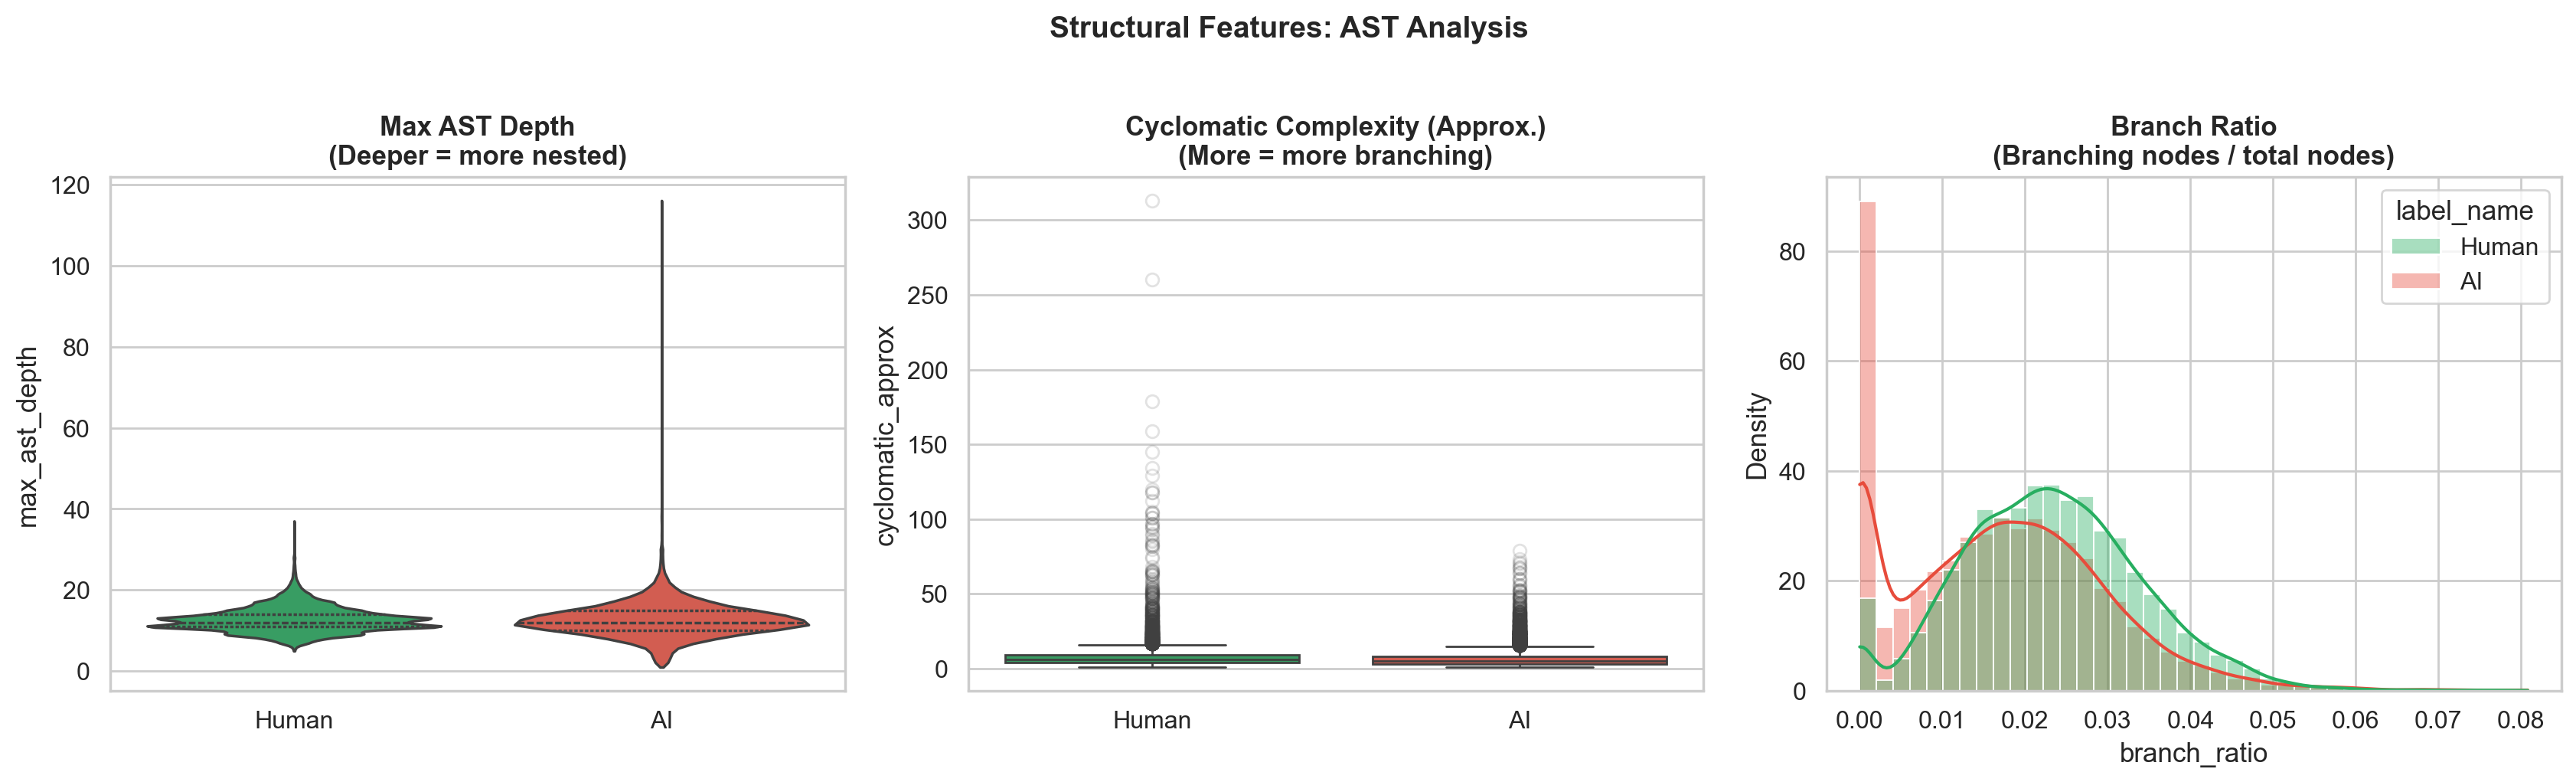

In [12]:
display(Markdown('### Violin/Boxplot: AST Depth, Cyclomatic Complexity, Branch Ratio'))
show_img('05_structural_ast', width=1000)

### AST Depth per Programming Language

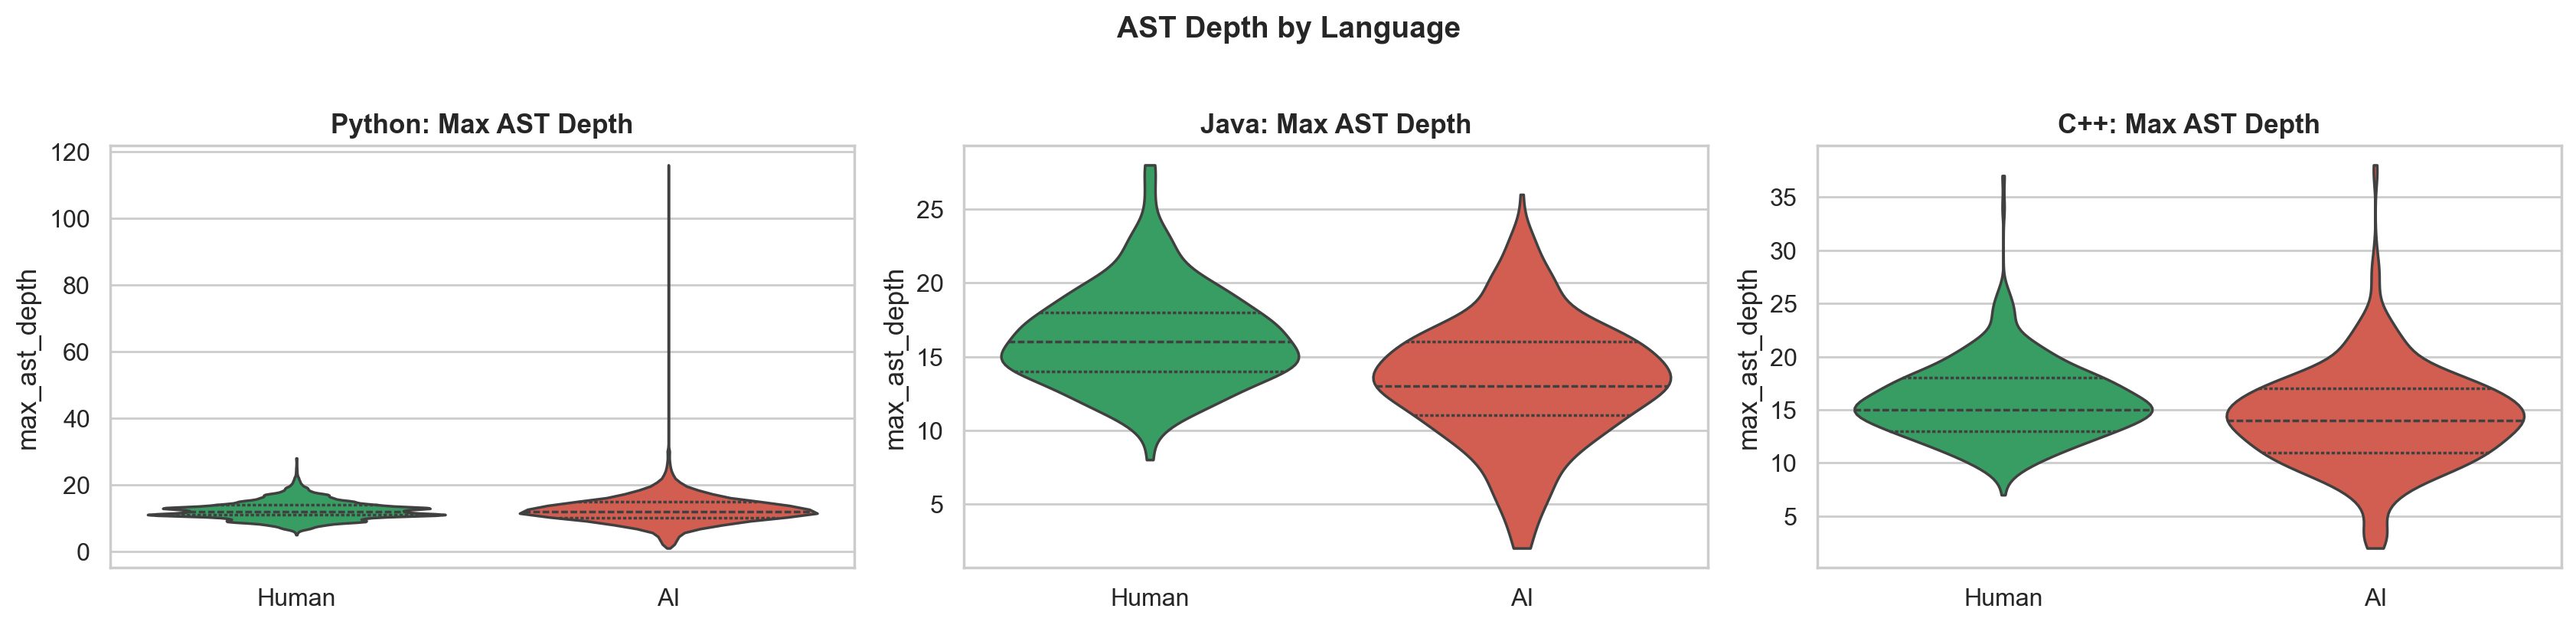

In [13]:
display(Markdown('### AST Depth per Programming Language'))
show_img('06_ast_depth_per_lang', width=1000)

### Nhan xet Group C — Structural:
- **max_ast_depth** khac biet nho giua Human va AI — khong phai feature tot nhat
- **branch_ratio** co tuong quan am voi AI (AI it dung branching hon)
- **cyclomatic_approx** cung tuong tu — AI code don gian hon
- **ast_node_count** gan nhu khong phan biet

---

# TASK 3: Phan tich Tuong quan & Feature Importance

## 3.1 Correlation Heatmap

In [14]:
# Compute correlation with label
corr_with_label = df_feat[ALL_FEATURES + ['label']].corr()['label'].drop('label')
corr_with_label = corr_with_label.sort_values(key=abs, ascending=False)

display(Markdown('### Feature Correlation with Label (sorted by |r|)'))
corr_df = pd.DataFrame({
    'Feature': corr_with_label.index,
    'Correlation (r)': corr_with_label.values,
    '|r|': corr_with_label.abs().values,
    'Direction': ['AI higher' if v > 0 else 'Human higher' for v in corr_with_label.values],
}).reset_index(drop=True)
corr_df.index += 1
display(corr_df.style.background_gradient(subset=['Correlation (r)'], cmap='RdBu_r', vmin=-0.5, vmax=0.5))

### Feature Correlation with Label (sorted by |r|)

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.2' currently installed).

### Full Correlation Heatmap

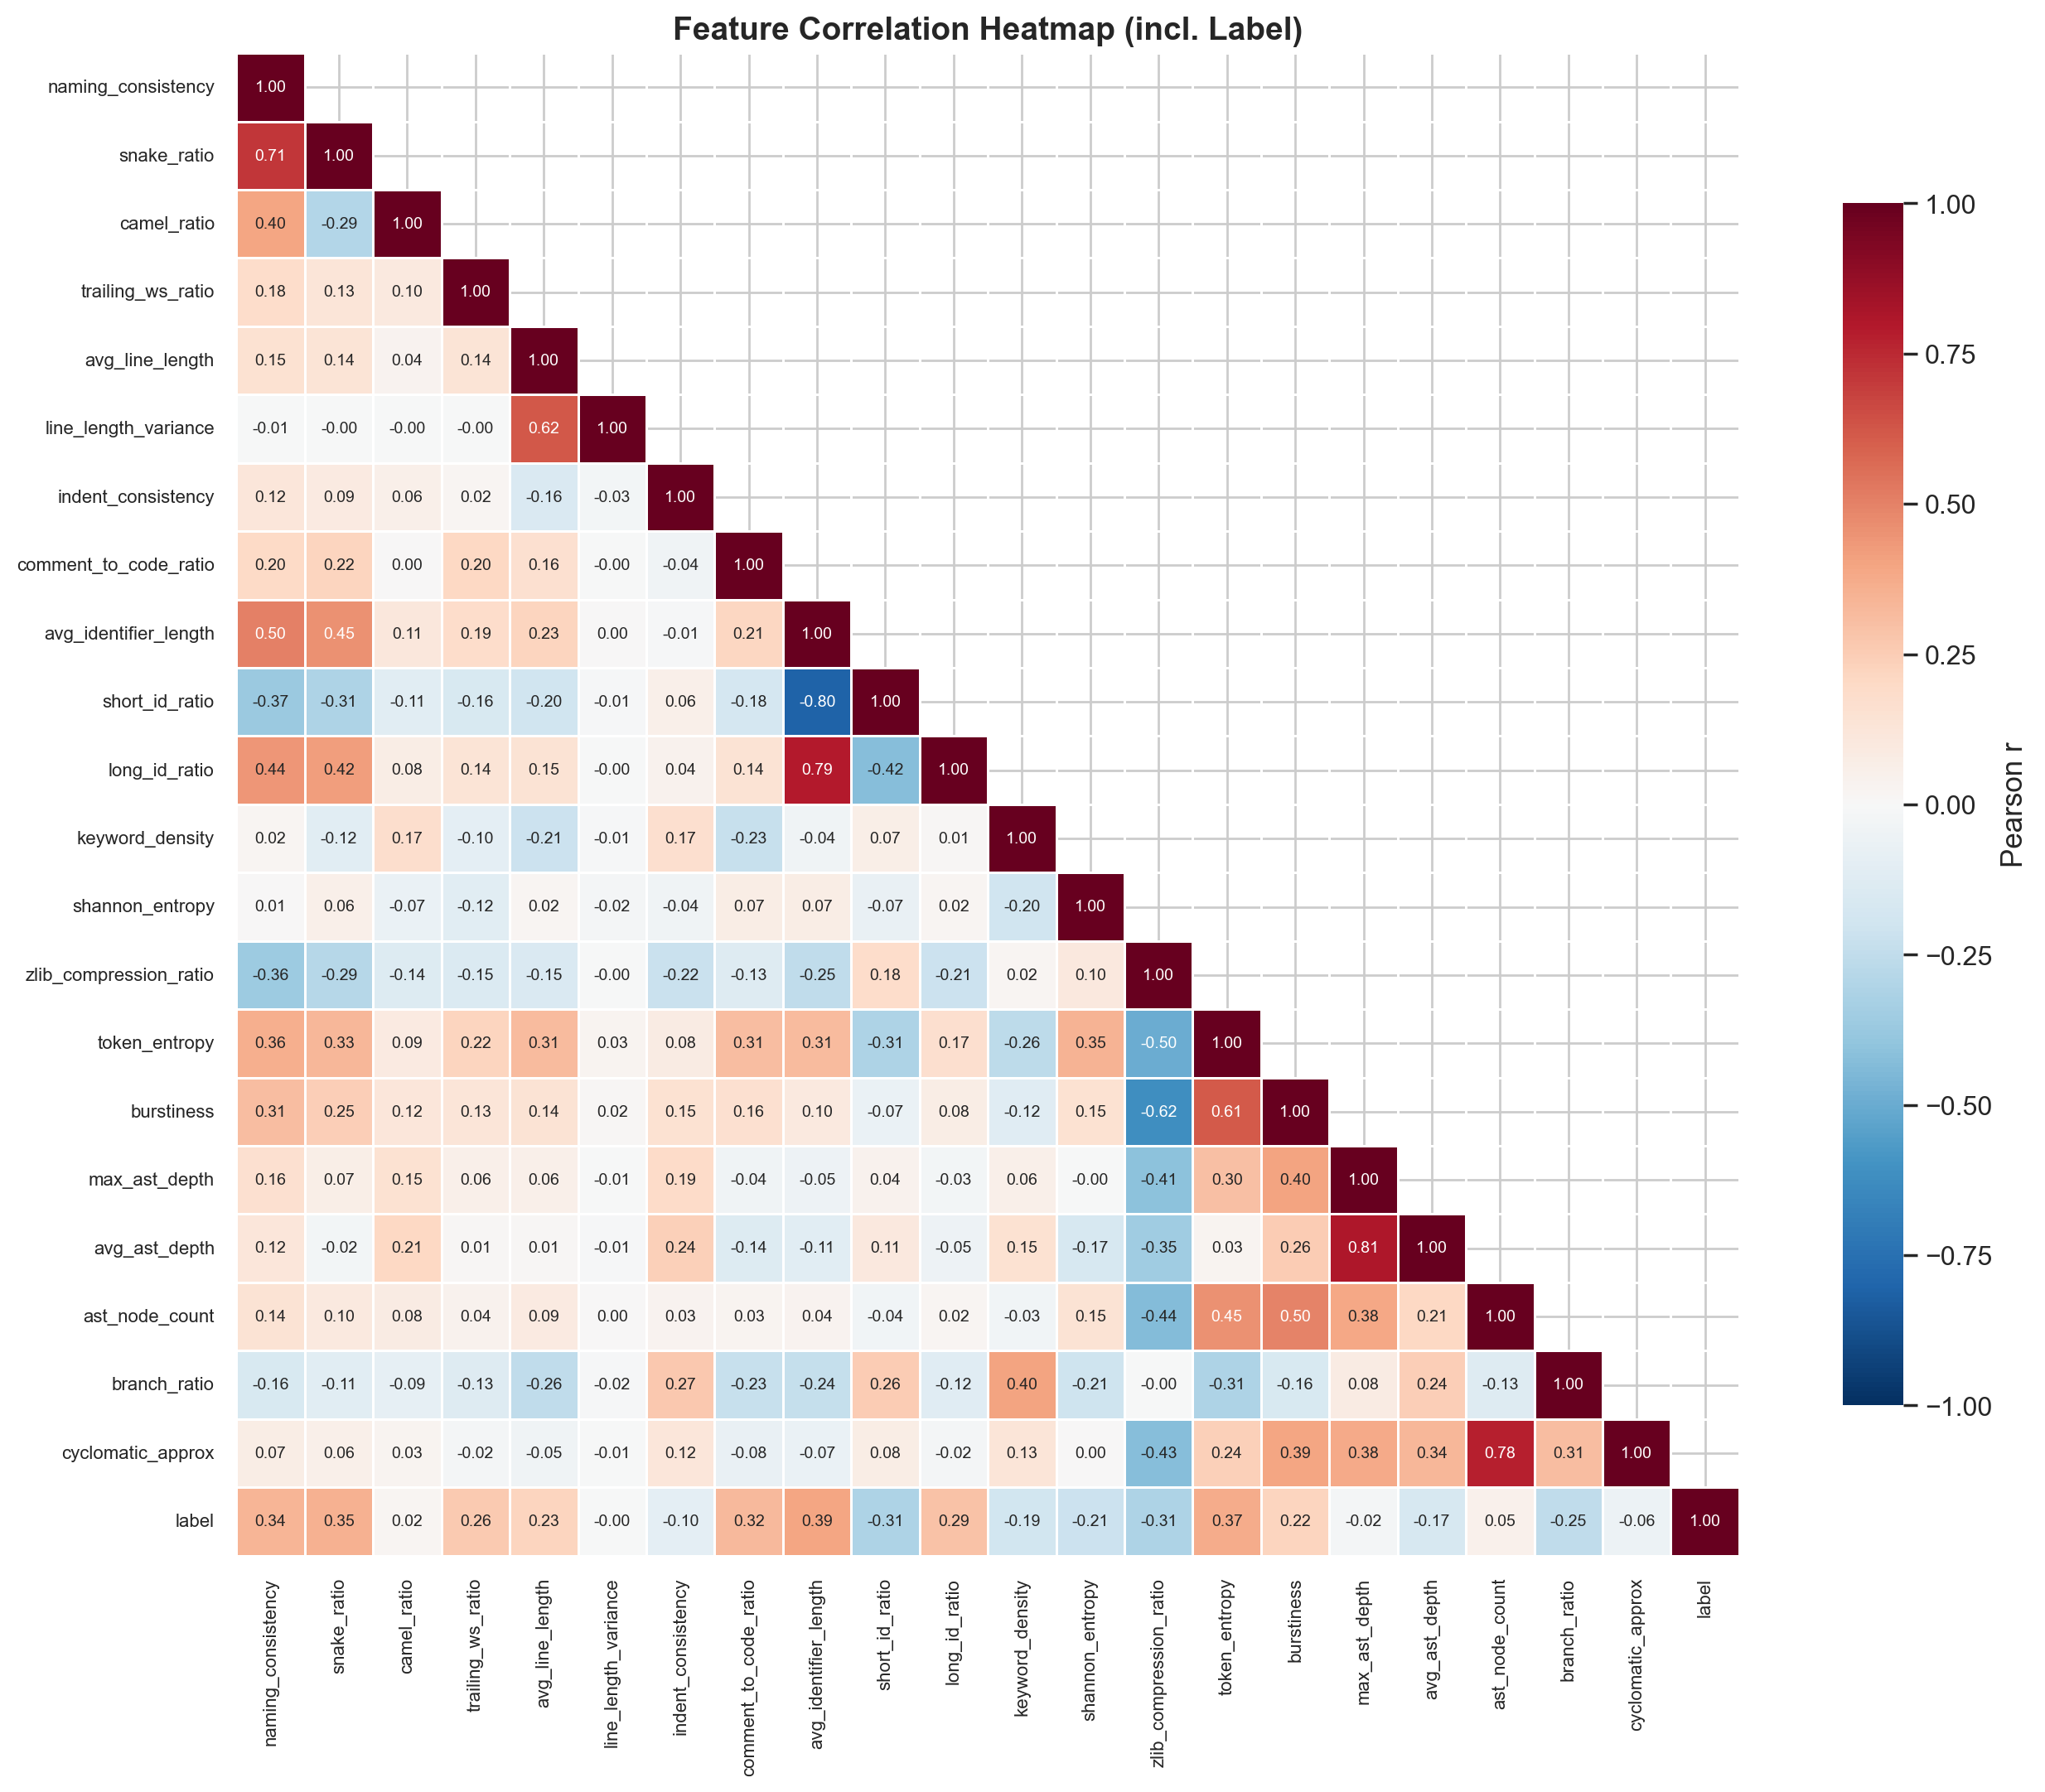

In [15]:
display(Markdown('### Full Correlation Heatmap'))
show_img('07_correlation_heatmap', width=850)

### Feature-Label Correlation Bar Chart

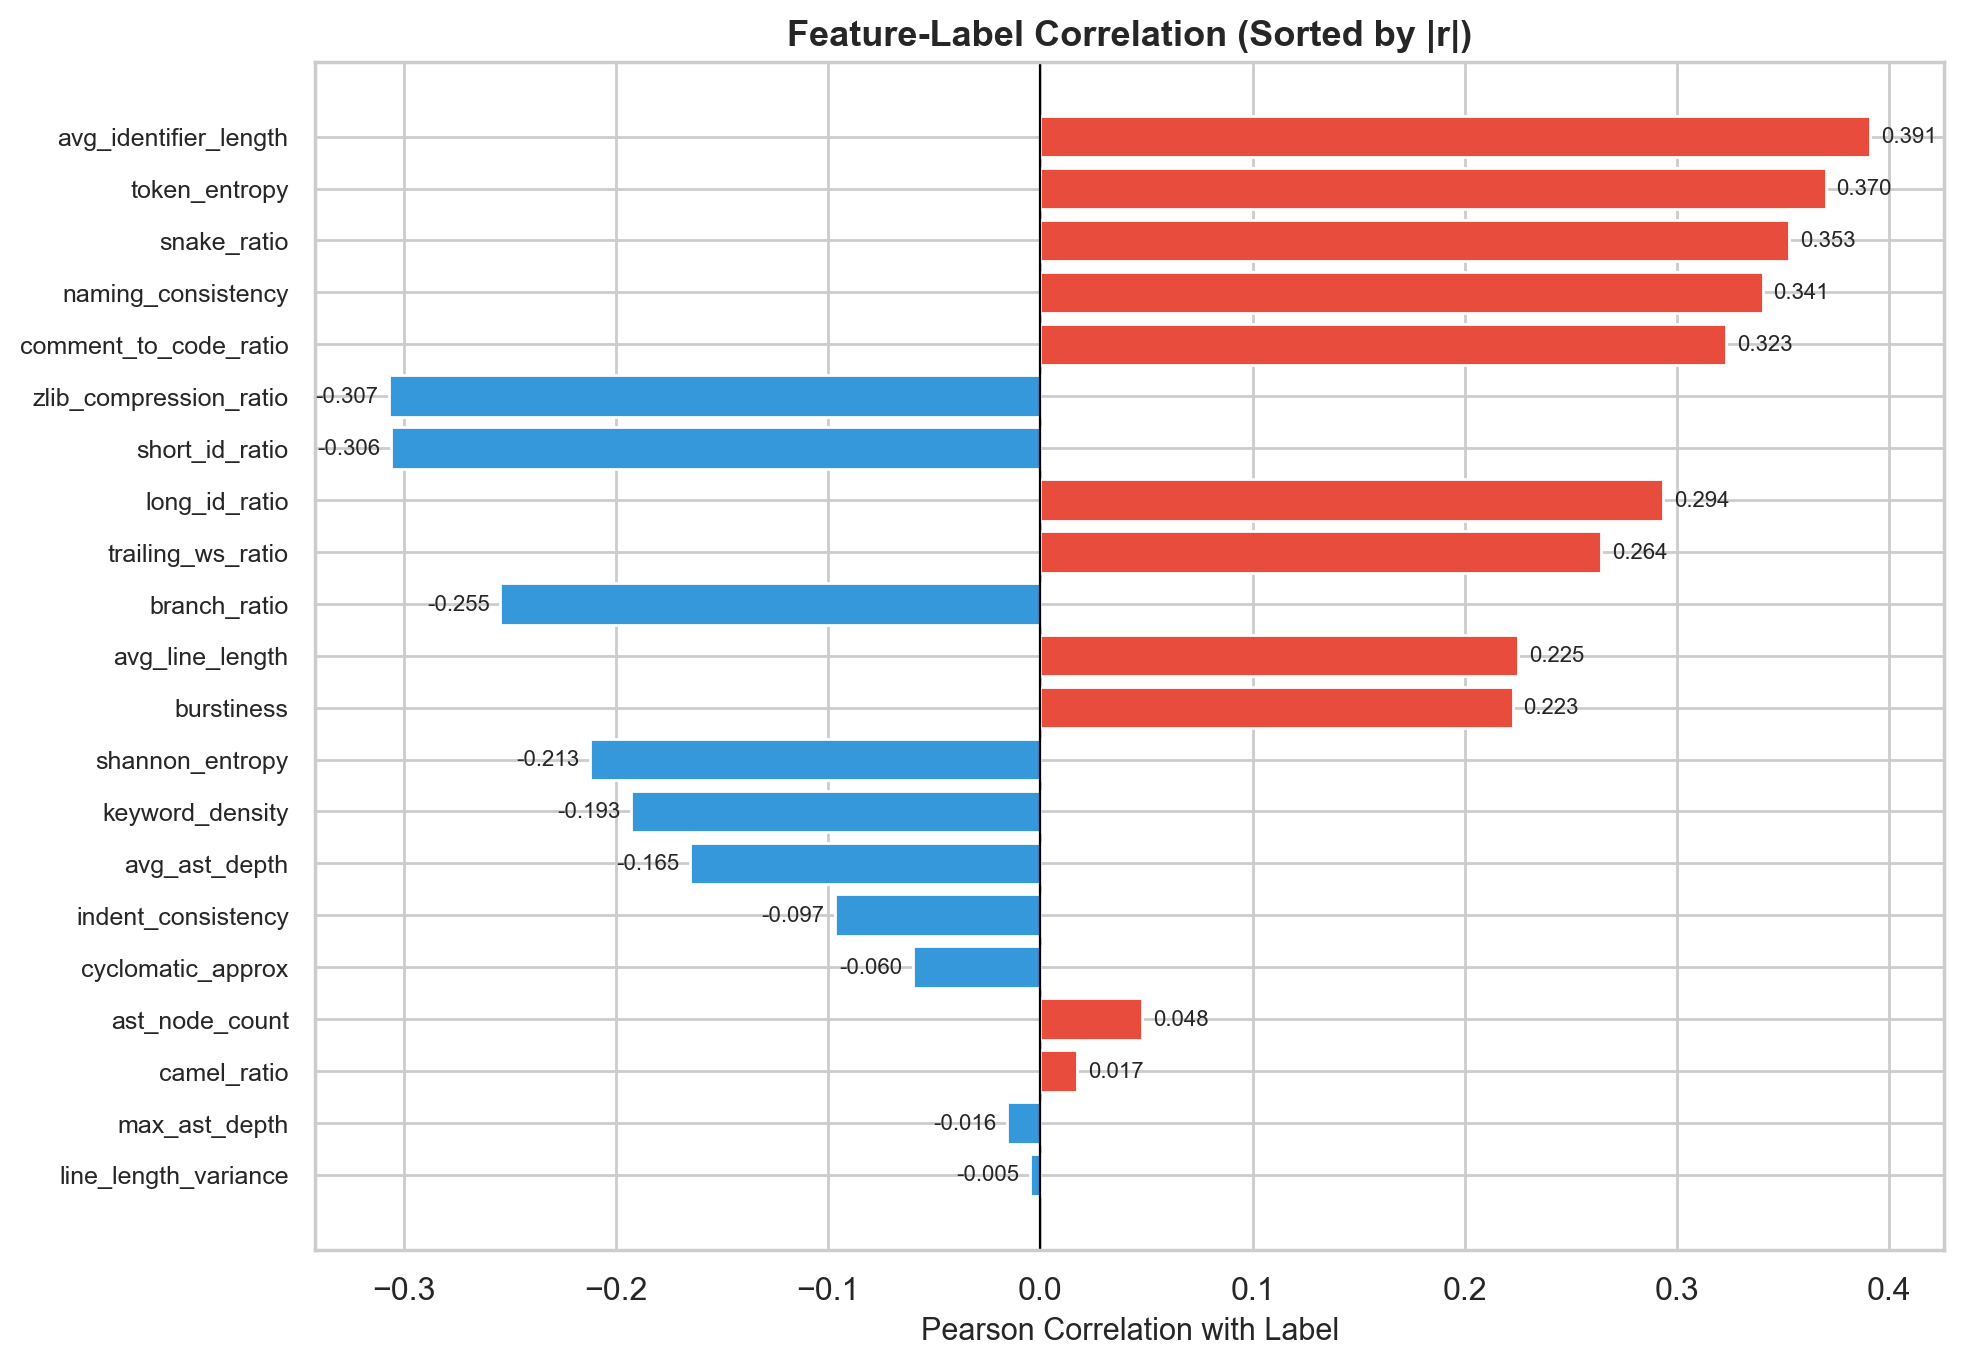

In [16]:
display(Markdown('### Feature-Label Correlation Bar Chart'))
show_img('08_label_correlation_bar', width=700)

## 3.2 Feature Importance — XGBoost 5-Fold CV

### Model Performance (chi voi 21 hand-crafted features):

| Metric | Value |
|---|---|
| **AUC-ROC** | 0.9721 +/- 0.0011 |
| **F1-Score** | 0.9214 +/- 0.0032 |

> Rat an tuong! Chi voi 21 features don gian, XGBoost da dat **AUC = 0.97**.

### Top-5 Features:

| Rank | Feature | Importance (Gain) |
|---|---|---|
| 1 | `indent_consistency` | 0.1278 |
| 2 | `avg_line_length` | 0.1247 |
| 3 | `shannon_entropy` | 0.0832 |
| 4 | `comment_to_code_ratio` | 0.0740 |
| 5 | `snake_ratio` | 0.0727 |

### XGBoost Feature Importance Chart

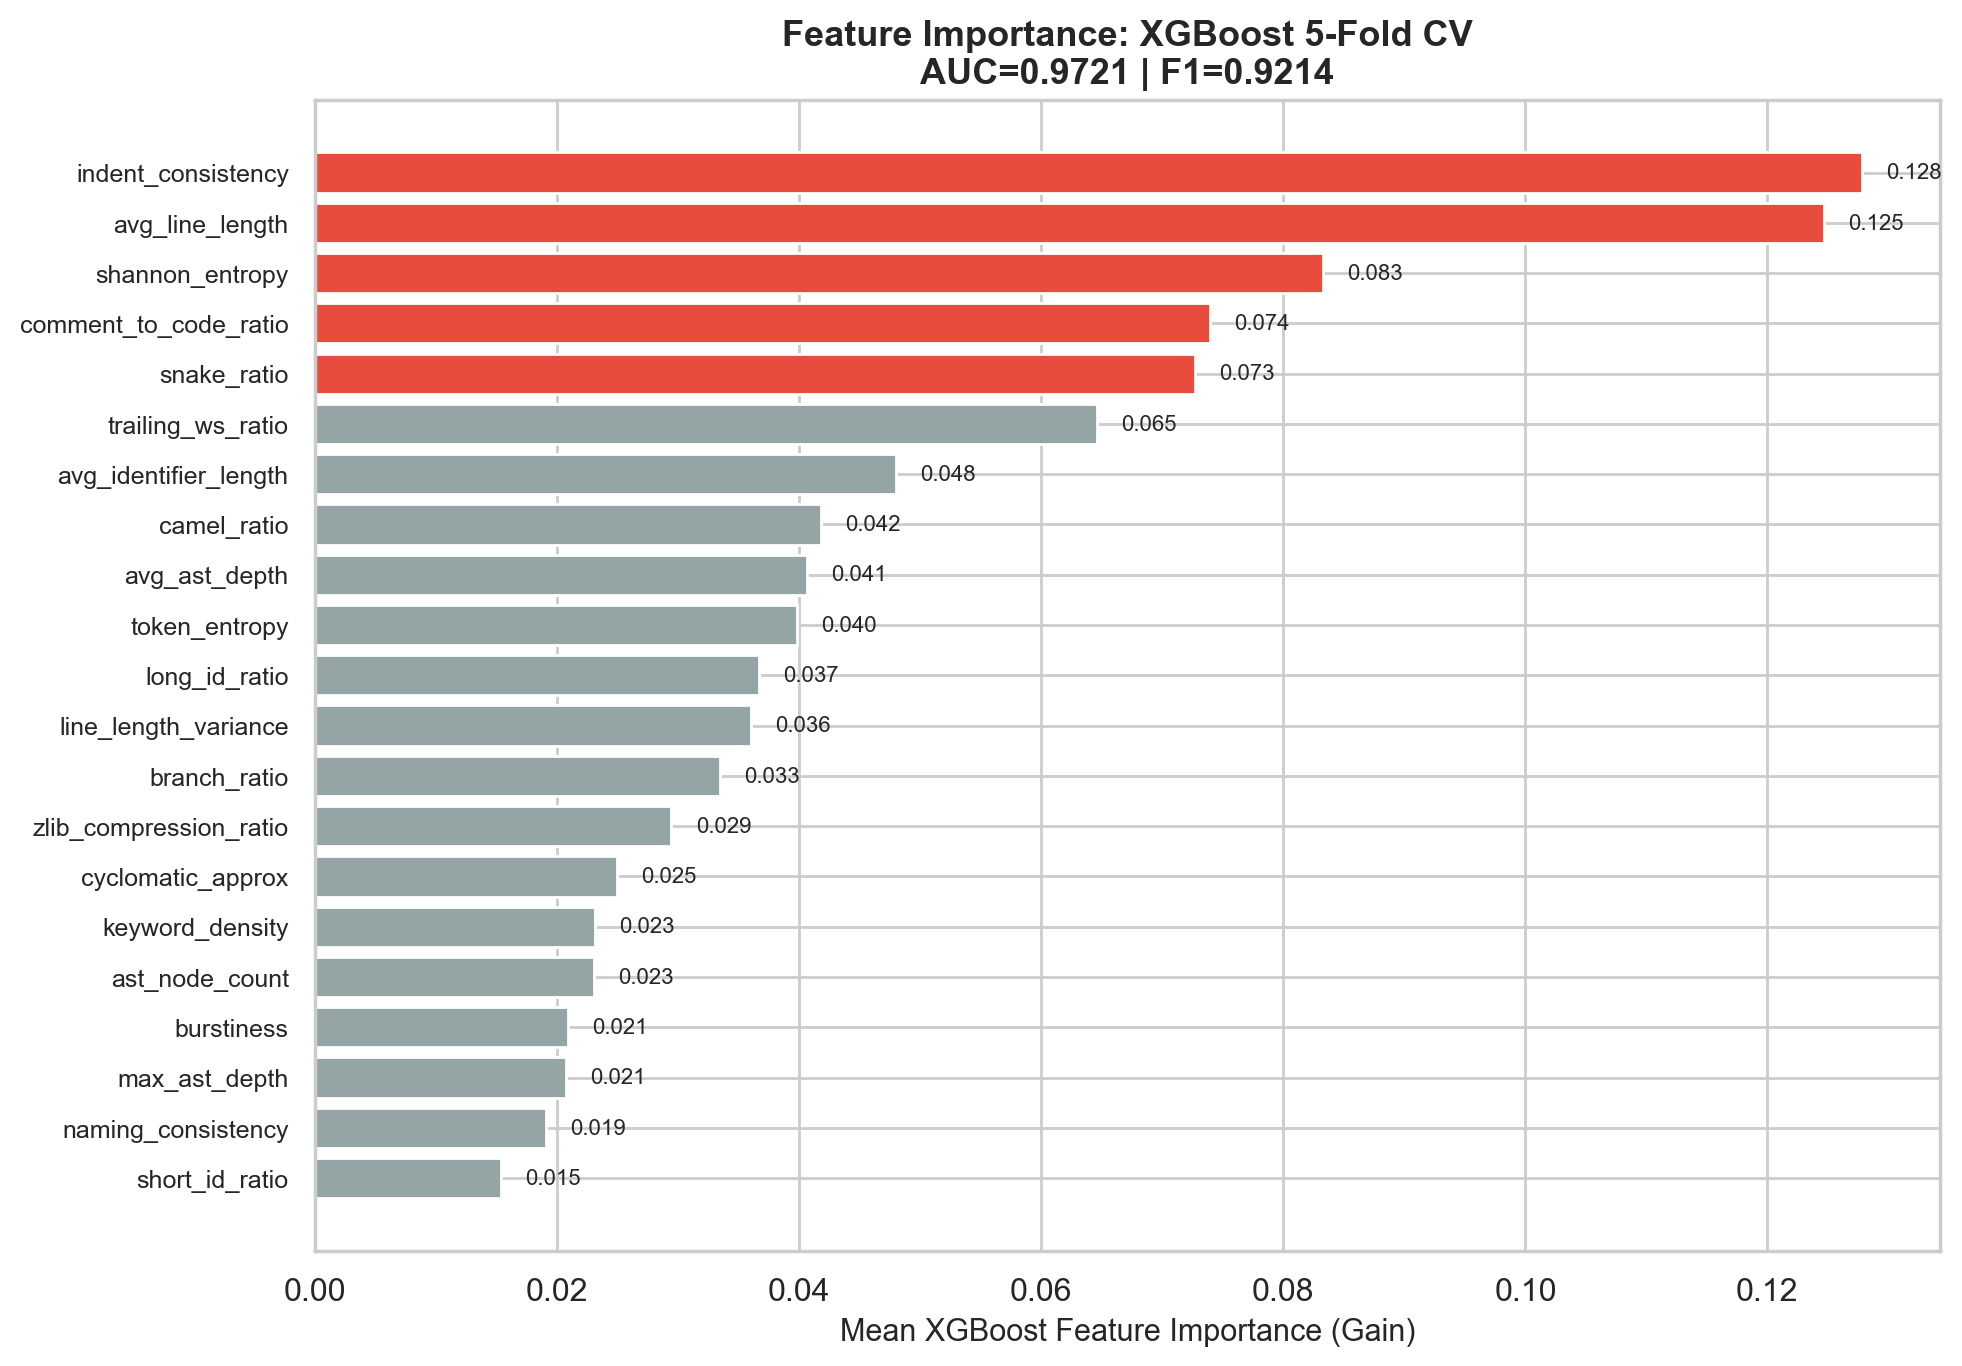

In [17]:
display(Markdown('### XGBoost Feature Importance Chart'))
show_img('09_xgboost_importance', width=750)

### Nhan xet Feature Importance:
- **`indent_consistency`** la feature quan trong nhat — AI format code cuc ky nhat quan
- **`avg_line_length`** — AI viet dong code dai hon, deu hon
- **`shannon_entropy`** — Do hon loan ky tu phan biet manh
- **`comment_to_code_ratio`** — AI viet comment nhieu hon
- **`snake_ratio`** — AI dung snake_case nhieu hon

**Luu y**: Correlation va Importance khong giong nhau!
- `avg_identifier_length` co correlation cao nhat (r=0.39) nhung XGBoost importance thap hon
- `indent_consistency` co correlation thap (r=-0.10) nhung la feature quan trong nhat trong XGBoost
- => XGBoost tim duoc cac **non-linear patterns** ma Pearson correlation khong thay

---

# TONG KET & BUOC TIEP THEO

## Ket qua chinh:

1. **Du lieu sach**: 0 duplicates, 0 leakage
2. **21 features** duoc trich xuat thanh cong tu 3 nhom (Stylometric, Statistical, Structural)
3. **XGBoost baseline: AUC = 0.9721** chi voi hand-crafted features
4. **Code AI de nen hon** (zlib ratio thap hon) — gia thuyet duoc xac nhan
5. **AI viet code phang hon** nhung su khac biet nho

## Buoc tiep theo (Phase 4-6):

| Phase | Noi dung | Uu tien |
|---|---|---|
| **Phase 4** | Train XGBoost/LightGBM tren **TOAN BO** 500k samples (khong chi 20k) | CAO |
| **Phase 5** | Fine-tune CodeBERT/GraphCodeBERT lam feature extractor | CAO |
| **Phase 6** | Ensemble: XGBoost + Transformer | TRUNG BINH |
| **Phase 7** | Inference tren test set & tao file nop | CAO |

In [18]:
# Quick summary stats
print('='*60)
print('  SUMMARY OF ALL OUTPUTS')
print('='*60)

print(f'\n  Charts saved to: img/phase2/')
for p in sorted(IMG_DIR.glob('*.png')):
    print(f'    - {p.name} ({p.stat().st_size/1024:.0f} KB)')

print(f'\n  Data saved to: data/processed/')
for p in sorted(PROCESSED_DIR.glob('*')):
    print(f'    - {p.name} ({p.stat().st_size/1024:.0f} KB)')

print(f'\n  Feature sample shape: {df_feat.shape}')
print(f'  Total features: {len(ALL_FEATURES)}')

  SUMMARY OF ALL OUTPUTS

  Charts saved to: img/phase2/
    - 01_integrity_distributions.png (137 KB)
    - 02_stylometric_violin.png (127 KB)
    - 03_stylometric_boxplots.png (164 KB)
    - 04_statistical_distributions.png (233 KB)
    - 05_structural_ast.png (192 KB)
    - 06_ast_depth_per_lang.png (170 KB)
    - 07_correlation_heatmap.png (401 KB)
    - 08_label_correlation_bar.png (138 KB)
    - 09_xgboost_importance.png (145 KB)

  Data saved to: data/processed/
    - feature_list.txt (0 KB)
    - sample_20k_features.parquet (9397 KB)

  Feature sample shape: (19998, 26)
  Total features: 21
